In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("pawzz_directory_report.csv", encoding="utf-8", low_memory=False)

print(df.shape)
df.head()


(500, 11)


,listing_id,source,name,category,phone,address,city,state,proof,status,notes
0,1,Community Referral,Pet Pet Boarding 1,Pet Boarding,9852148024,NaN,Noida,Uttar Pradesh,Justdial page,Ready,NaN
1,2,Google Maps,Care Pet Shop 2,Pet Shop,+91 6549496895,NaN,Delhi,Delhi,WhatsApp message,Submitted,NaN
2,3,WhatsApp Submission,Tails Pet Trainer 3,Pet Trainer,NaN,Near main road,Jaipur,Rajasthan,Instagram page,Submitted,Address incomplete
3,4,Justdial,Pet Pet Trainer 4,Pet Trainer,9813727672,Residential area,Bangalore,Karnataka,Instagram page,Submitted,Possible duplicate
4,5,Justdial,Paws Feeder 5,Feeder,9415172416,Opposite park,Jaipur,Rajasthan,Maps listing,Submitted,Phone missing


#### Column Names

In [3]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns


Index(['listing_id', 'source', 'name', 'category', 'phone', 'address', 'city',
       'state', 'proof', 'status', 'notes'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   listing_id  500 non-null    int64 
 1   source      500 non-null    object
 2   name        500 non-null    object
 3   category    500 non-null    object
 4   phone       329 non-null    object
 5   address     403 non-null    object
 6   city        500 non-null    object
 7   state       500 non-null    object
 8   proof       500 non-null    object
 9   status      500 non-null    object
 10  notes       363 non-null    object
dtypes: int64(1), object(10)
memory usage: 43.1+ KB


In [6]:
df.isnull().sum()

listing_id      0
source          0
name            0
category        0
phone         171
address        97
city            0
state           0
proof           0
status          0
notes         137
dtype: int64

#### Clean Phone Numbers

In [8]:
import re

def clean_phone(phone):
    if pd.isna(phone):
        return None
    phone = re.sub(r"\D", "", str(phone))
    if len(phone) == 10:
        return "+91" + phone
    if len(phone) == 12 and phone.startswith("91"):
        return "+" + phone
    return None

df["clean_phone"] = df["phone"].apply(clean_phone)


#### Normalize Text Fields (Name, City, Area)

In [9]:
def normalize_text(text):
    if pd.isna(text):
        return None
    return str(text).strip().title()

for col in ["name", "city", "area", "category"]:
    if col in df.columns:
        df[col] = df[col].apply(normalize_text)


#### Identify Missing

In [10]:
required_fields = ["name", "category", "city", "clean_phone"]

df["missing_required"] = df[required_fields].isnull().any(axis=1)


#### Assign Pipeline Status Automatically

In [11]:
def assign_status(row):
    if row["missing_required"]:
        return "Needs Fix"
    if pd.isna(row.get("verified_by")):
        return "Ready for Verification"
    return "Verified"

df["pipeline_status"] = df.apply(assign_status, axis=1)


#### Detect Phone based duplicates


In [12]:
df["duplicate_phone"] = df.duplicated(subset=["clean_phone"], keep=False)


#### Name and City fuzzy duplicates

In [14]:
df["name_city_key"] = df["name"].str.lower() + "_" + df["city"].str.lower()
df["duplicate_name_city"] = df.duplicated(subset=["name_city_key"], keep=False)


#### Red Flag Detection

In [16]:
def safe_isnull(col):
    return df[col].isnull() if col in df.columns else False


In [17]:
df["red_flag"] = (
    df["clean_phone"].isnull()
    | df["name"].str.len().lt(4)
    | safe_isnull("area")
)


#### Final Clean Output Files

In [18]:
df.to_csv("pawzz_directory_cleaned.csv", index=False)

df[df["pipeline_status"] == "Needs Fix"].to_csv(
    "pawzz_needs_fix.csv", index=False
)

df[df["duplicate_phone"] | df["duplicate_name_city"]].to_csv(
    "pawzz_duplicates.csv", index=False
)


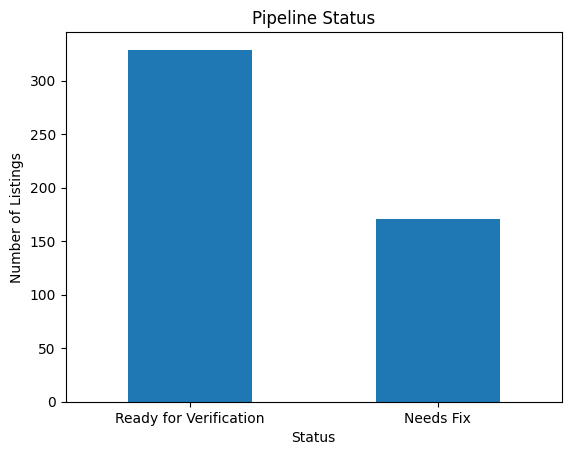

In [21]:
df["pipeline_status"].value_counts().plot(kind="bar")
plt.title("Pipeline Status")
plt.xlabel("Status")
plt.ylabel("Number of Listings")
plt.xticks(rotation=0)
plt.show()


#### This chart shows how many listings are currently in each stage of the data pipeline, helping identify where data cleaning or verification is required.

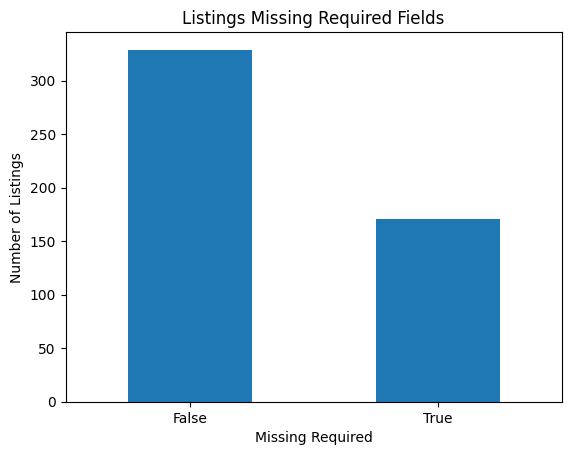

In [23]:
df["missing_required"].value_counts().plot(kind="bar")
plt.title("Listings Missing Required Fields")
plt.xlabel("Missing Required")
plt.ylabel("Number of Listings")
plt.xticks(rotation=0)
plt.show()


#### This chart highlights listings that are missing mandatory information such as name, category, city, or phone number and need correction before verification.

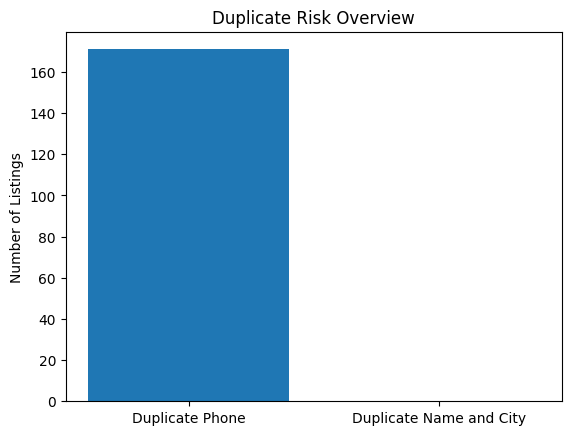

In [25]:
duplicate_counts = {
    "Duplicate Phone": df["duplicate_phone"].sum(),
    "Duplicate Name and City": df["duplicate_name_city"].sum()
}

plt.bar(duplicate_counts.keys(), duplicate_counts.values())
plt.title("Duplicate Risk Overview")
plt.ylabel("Number of Listings")
plt.show()


#### This chart indicates potential duplicate listings based on matching phone numbers or similar names within the same city, which require manual review.

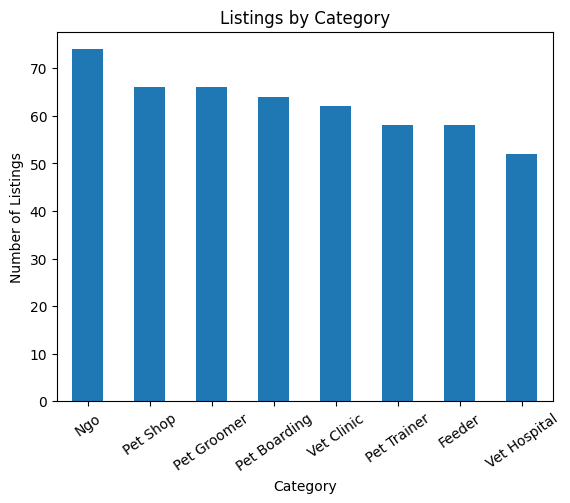

In [28]:
df["category"].value_counts().plot(kind="bar")
plt.title("Listings by Category")
plt.xlabel("Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=35)
plt.show()


#### This chart shows the distribution of listings across different service categories, helping assess coverage balance within the directory.